# Cat and Dog Classification - week 5
Classify images of cats and dogs using Histogram of Oriented Gradients (HOG) for feature extraction and Decision Tree, Random Forest, Linear Regression for classification and compair them. 

In [14]:
import os
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.feature import hog
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from skimage.io import imsave


In [6]:
# Load dataset
data_dir = './dataset'
images, labels = [], []

for file in os.listdir(data_dir):
    if file.endswith('.jpg'):
        img_path = os.path.join(data_dir, file)
        if file.startswith('cat'):
            labels.append(0)  # Cat
        elif file.startswith('dog'):
            labels.append(1)  # Dog
        else:
            continue

        img = imread(img_path)
        img = rgb2gray(img)  # Convert to grayscale
        images.append(img)

images = np.array(images)
labels = np.array(labels)
print('Images shape:', images.shape)
print('Labels shape:', labels.shape)
print(f'Number of cats: {np.sum(labels == 0)}')
print(f'Number of dogs: {np.sum(labels == 1)}')

Images shape: (615, 128, 128)
Labels shape: (615,)
Number of cats: 260
Number of dogs: 355


In [ ]:
def extract_hog_features(images, visualize=False):
    """Extract HOG features from a list of grayscale images.
    
    Args:
        images: Array of grayscale images (N, 128, 128).
        visualize: If True, return HOG visualizations.
    
    Returns:
        hog_features: Array of HOG features (N, feature_size).
        hog_images: Array of HOG visualizations (N, 128, 128) if visualize=True, else None.
    """
    hog_features = []
    hog_images = [] if visualize else None
  
    orientations = 9
    pixels_per_cell = (8, 8)
    cells_per_block = (2, 2)
    
    for img in images:
        if visualize:
            features, hog_img = hog(img, orientations=orientations, pixels_per_cell=pixels_per_cell, cells_per_block=cells_per_block, visualize=True, feature_vector=True)
            hog_images.append(hog_img)
        else:
            features = hog(img, orientations=orientations, pixels_per_cell=pixels_per_cell, cells_per_block=cells_per_block, visualize=False, feature_vector=True)
        
        hog_features.append(features)
    
    hog_features = np.array(hog_features)
    if visualize:
        hog_images = np.array(hog_images)
    
    print(f'HOG features shape: {hog_features.shape}')
    return hog_features, hog_images

In [21]:
def split_and_save_dataset(images, labels, test_size=0.2, train_dir='./dog-cat/train', test_dir='./dog-cat/test'):
    """Split dataset into training and test sets and save images to separate directories.
    
    Args:
        images: Array of grayscale images (N, 128, 128).
        labels: Array of labels (0 for cat, 1 for dog).
        test_size: Fraction of data for test set.
        train_dir: Directory to save training images.
        test_dir: Directory to save test images.
    
    Returns:
        X_train, X_test: HOG features for training and test sets.
        y_train, y_test: Labels for training and test sets.
        idx_train, idx_test: Indices for training and test sets.
    """
    # Split the data using stratified sampling to maintain class balance
    indices = np.arange(len(images))
    idx_train, idx_test, y_train, y_test = train_test_split(
        indices, labels, 
        test_size=test_size, 
        random_state=42, 
        stratify=labels
    )
    
    # Extract HOG features for training and test sets
    train_images = images[idx_train]
    test_images = images[idx_test]
    
    X_train, _ = extract_hog_features(train_images, visualize=False)
    X_test, hog_images_test = extract_hog_features(test_images, visualize=True)  # HOG visualization برای تست

    
    # Create directories if they don't exist
    os.makedirs(os.path.join(train_dir, 'cats'), exist_ok=True)
    os.makedirs(os.path.join(train_dir, 'dogs'), exist_ok=True)
    os.makedirs(os.path.join(test_dir, 'cats'), exist_ok=True)
    os.makedirs(os.path.join(test_dir, 'dogs'), exist_ok=True)
    
    # Save training images
    for i, (idx, label) in enumerate(zip(idx_train, y_train)):
        class_name = 'cats' if label == 0 else 'dogs'
        filename = f'{class_name}_{i}.png'
        filepath = os.path.join(train_dir, class_name, filename)
        # Convert float image to uint8 format for saving
        img_to_save = (images[idx] * 255).astype(np.uint8)
        imsave(filepath, img_to_save)
    
    # Save test images
    for i, (idx, label) in enumerate(zip(idx_test, y_test)):
        class_name = 'cats' if label == 0 else 'dogs'
        filename = f'{class_name}_{i}.png'
        filepath = os.path.join(test_dir, class_name, filename)
        # Convert float image to uint8 format for saving
        img_to_save = (images[idx] * 255).astype(np.uint8)
        imsave(filepath, img_to_save)
    
    print(f'Training set: {len(X_train)} samples')
    print(f'Test set: {len(X_test)} samples')
    print(f'Training cats: {np.sum(y_train == 0)}, dogs: {np.sum(y_train == 1)}')
    print(f'Test cats: {np.sum(y_test == 0)}, dogs: {np.sum(y_test == 1)}')
    
    return X_train, X_test, y_train, y_test, idx_train, idx_test, test_images, hog_images_test


In [22]:
# Train models using scikit learn

X_train, X_test, y_train, y_test, idx_train, idx_test, images_test, hog_images_test = split_and_save_dataset(images, labels)



# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

# Random Forest
# Using RandomForestClassifier as it's a classification task
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

# Linear Regression
# Adapting Linear Regression for binary classification by thresholding the output
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred_continuous = lr_model.predict(X_test)
lr_pred = (lr_pred_continuous > 0.5).astype(int) # Thresholding at 0.5
lr_accuracy = accuracy_score(y_test, lr_pred)


print(f'Decision Tree Accuracy: {dt_accuracy:.4f}')
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')
print(f'Linear Regression Accuracy: {lr_accuracy:.4f}')

HOG features shape: (492, 8100)
HOG features shape: (123, 8100)
Training set: 492 samples
Test set: 123 samples
Training cats: 208, dogs: 284
Test cats: 52, dogs: 71
Decision Tree Accuracy: 0.8618
Random Forest Accuracy: 0.9350
Linear Regression Accuracy: 0.9268


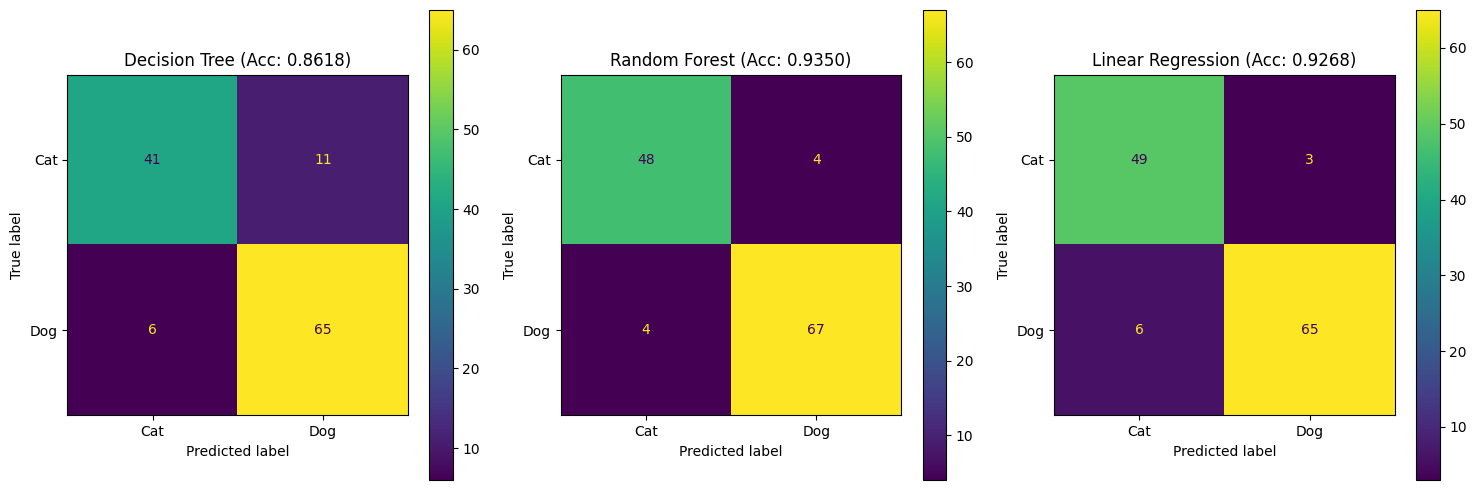

In [17]:
# Compare models with confusion matrices
# A confusion matrix is a table that is often used to describe the performance of a classification model.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
ConfusionMatrixDisplay(cm_dt, display_labels=['Cat', 'Dog']).plot(ax=axes[0])
axes[0].set_title(f'Decision Tree (Acc: {dt_accuracy:.4f})')

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['Cat', 'Dog']).plot(ax=axes[1])
axes[1].set_title(f'Random Forest (Acc: {rf_accuracy:.4f})')


# Linear Regression
cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=['Cat', 'Dog']).plot(ax=axes[2])
axes[2].set_title(f'Linear Regression (Acc: {lr_accuracy:.4f})')


# finally we show result
plt.tight_layout()
plt.show()

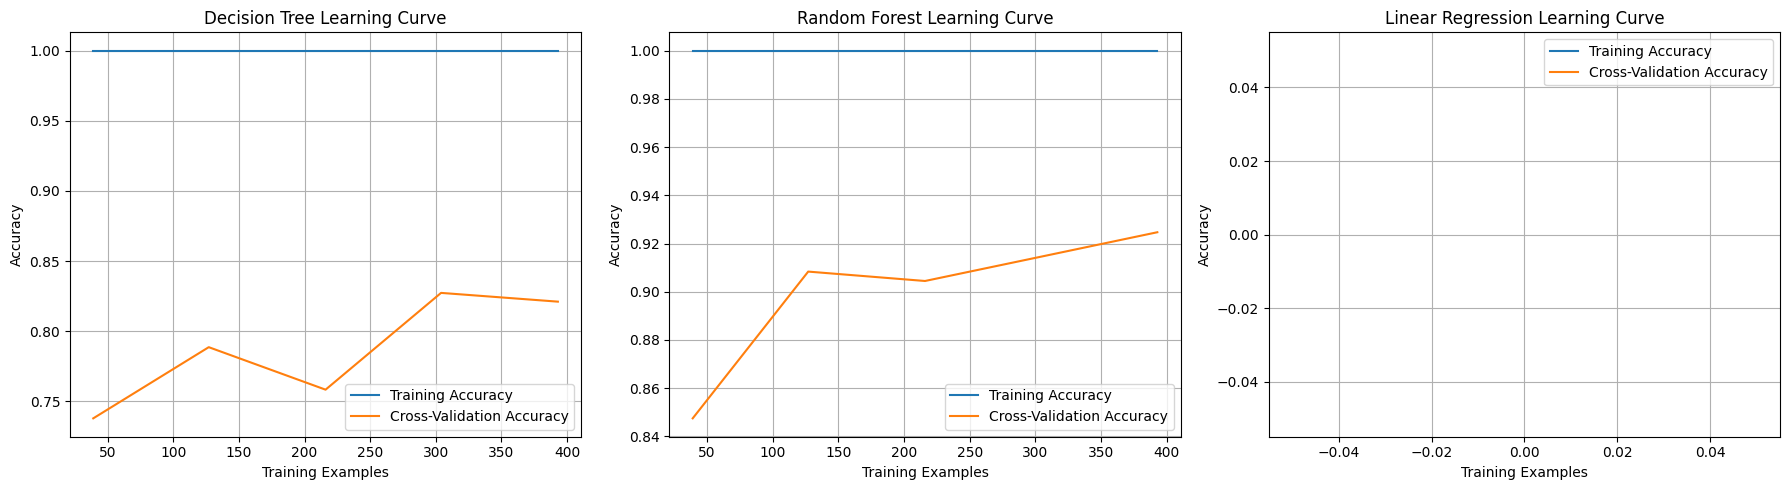

In [18]:
# Learning curves
# A learning curve shows the validation and training score of an estimator for varying numbers of training samples.
def plot_learning_curve(estimator, title, X, y, ax, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy'
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    ax.plot(train_sizes, train_scores_mean, label='Training Accuracy')
    ax.plot(train_sizes, test_scores_mean, label='Cross-Validation Accuracy')
    ax.set_title(title)
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='best')
    ax.grid(True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot learning curves for all models
plot_learning_curve(dt_model, 'Decision Tree Learning Curve', X_train, y_train, axes[0])
plot_learning_curve(rf_model, 'Random Forest Learning Curve', X_train, y_train, axes[1])
plot_learning_curve(lr_model, 'Linear Regression Learning Curve', X_train, y_train, axes[2])


plt.tight_layout()
plt.show()

### It seams there is wrong with Linear Regression learning curve, Can you guess why?!

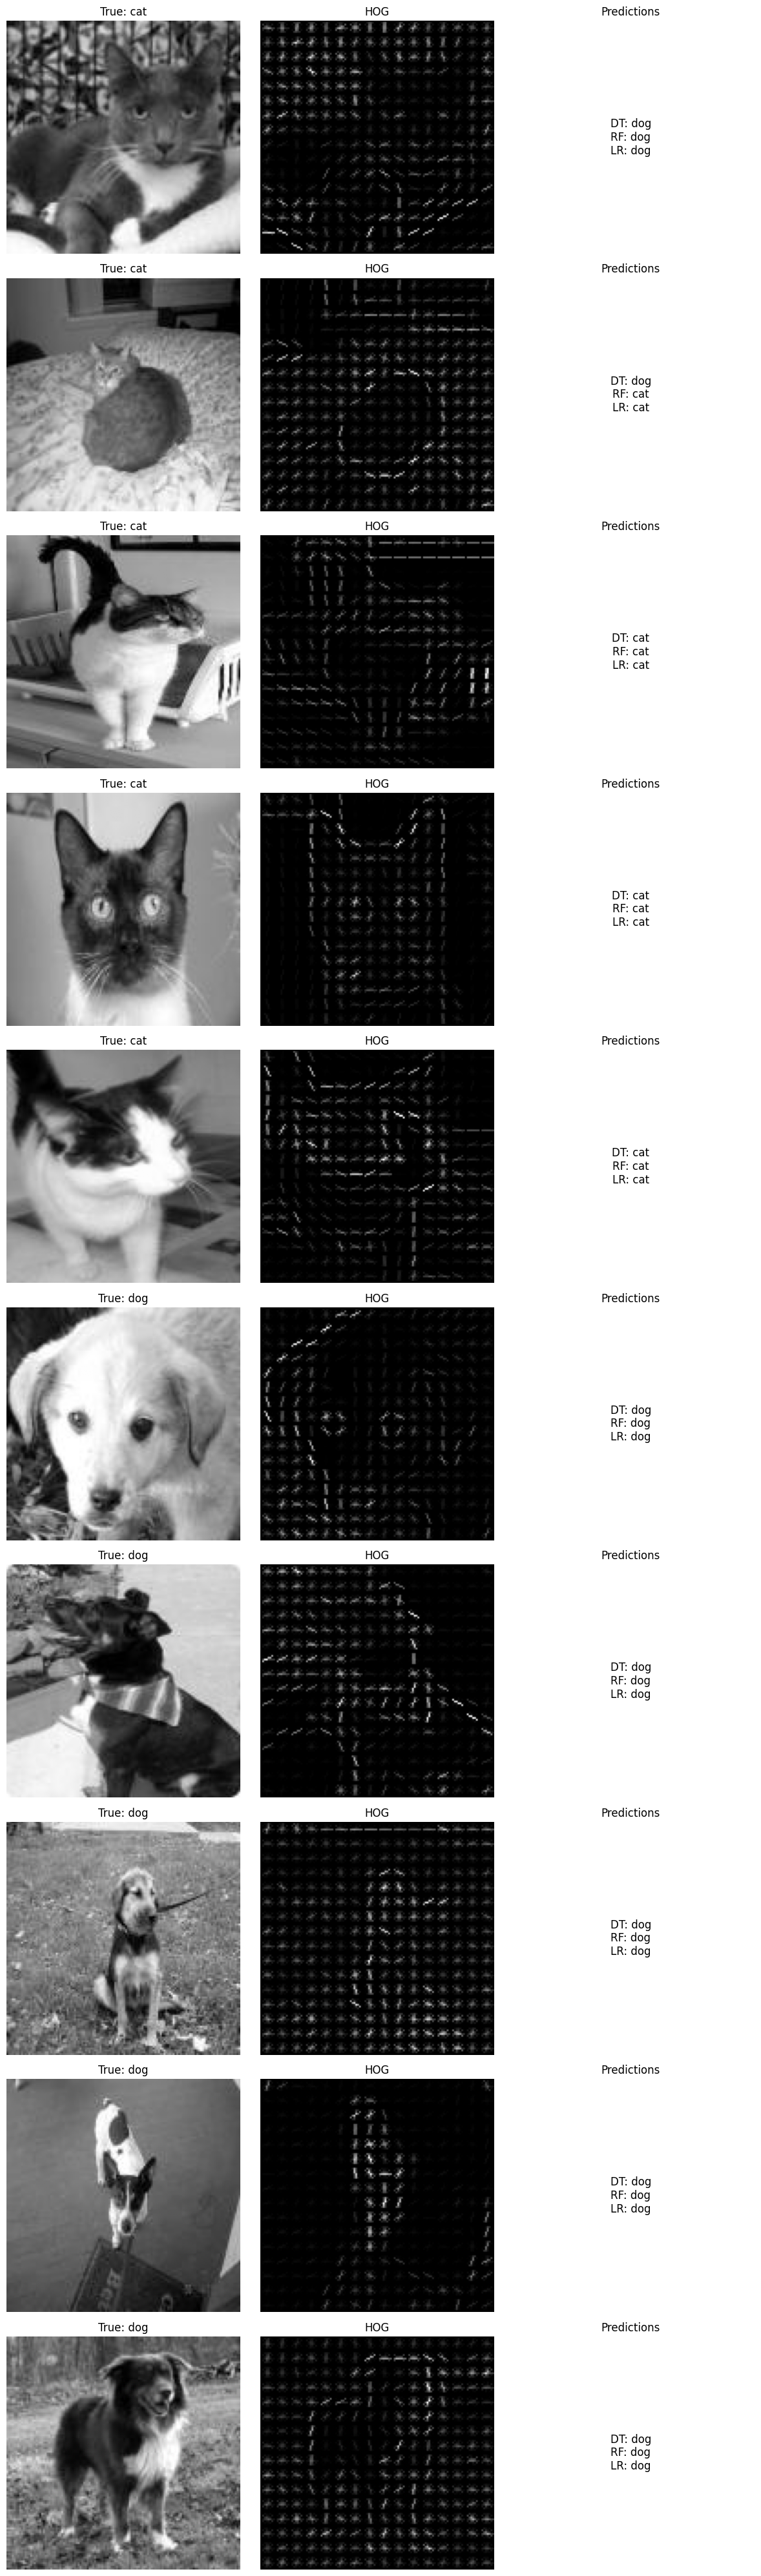

In [23]:
# Visualize sample results
classes = ['cat', 'dog']
cat_indices = [idx for idx in idx_test if y_test[np.where(idx_test == idx)[0][0]] == 0]
dog_indices = [idx for idx in idx_test if y_test[np.where(idx_test == idx)[0][0]] == 1]
sample_indices = cat_indices[:min(5, len(cat_indices))] + dog_indices[:min(5, len(dog_indices))]

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))
for i, idx in enumerate(sample_indices):
    true_label = y_test[np.where(idx_test == idx)[0][0]]
    dt_pred_label = dt_pred[np.where(idx_test == idx)[0][0]]
    rf_pred_label = rf_pred[np.where(idx_test == idx)[0][0]]
    lr_pred_label = lr_pred[np.where(idx_test == idx)[0][0]]

    # Original image
    ax = axes[i, 0] if len(sample_indices) > 1 else axes[0]
    ax.imshow(images_test[np.where(idx_test == idx)[0][0]], cmap='gray')
    ax.set_title(f'True: {classes[true_label]}')
    ax.axis('off')

    # HOG image
    ax = axes[i, 1] if len(sample_indices) > 1 else axes[1]
    ax.imshow(hog_images_test[np.where(idx_test == idx)[0][0]], cmap='gray')
    ax.set_title('HOG')
    ax.axis('off')

    # Predictions
    ax = axes[i, 2] if len(sample_indices) > 1 else axes[2]
    ax.text(0.5, 0.5, f'DT: {classes[dt_pred_label]}\nRF: {classes[rf_pred_label]}\nLR: {classes[lr_pred_label]}',
            fontsize=12, ha='center', va='center')
    ax.set_title('Predictions')
    ax.axis('off')

plt.tight_layout()
plt.show()